# Groover's Algorithm
Improve probability of finding the correct answer in an unstructured search problem.

This algorithm has these execution steps:

- Define the Oracle 
- Define the Diffusion Operator
- Construct the Grover's algorithm circuit
- Run the simulation

In [96]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer

In [97]:
def grover_oracle():
    oracle = QuantumCircuit(2)
    oracle.cz(0, 1)  # Mark the state |11⟩

    return oracle

In [98]:
def difusion_operator():
    diffusion = QuantumCircuit(2)
    diffusion.h([0, 1])  
    diffusion.x([0, 1])  
    diffusion.cz(0, 1)   
    diffusion.x([0, 1])  
    diffusion.h([0, 1]) 

    return diffusion

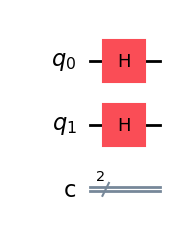

In [99]:
qc= QuantumCircuit(2, 2)
qc.h([0, 1])  
qc.draw('mpl')


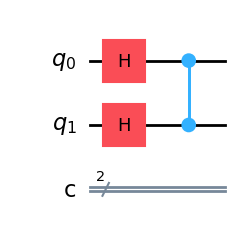

In [100]:

qc = qc.compose(grover_oracle())
qc.draw('mpl')


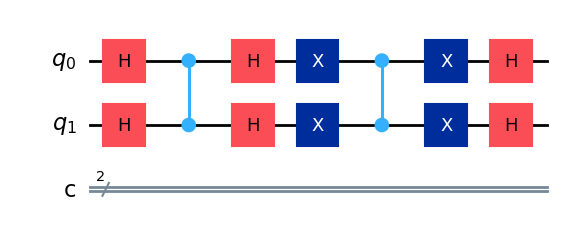

In [101]:

qc = qc.compose(difusion_operator())
qc.draw('mpl')

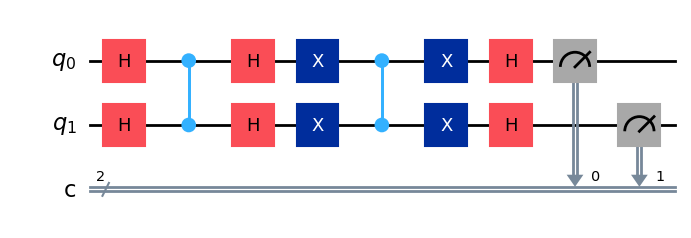

In [102]:

qc.measure([0, 1], [0, 1])
qc.draw('mpl')


In [103]:


simulator = Aer.get_backend('aer_simulator')
job = simulator.run(qc, shots=1024)
result = job.result()

{'11': 1024}


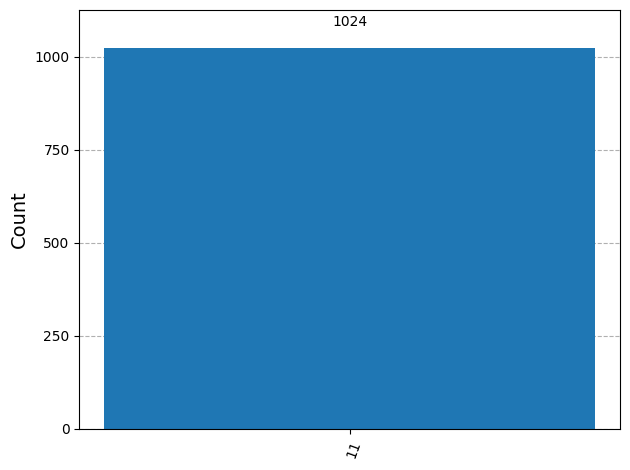

In [104]:
counts = result.get_counts(qc)
print(counts)

plot_histogram(counts)
